In [1]:
# ---
# jupyter:
#   jupytext:
#     formats: py:percent,ipynb
#     text_representation:
#       extension: .py
#       format_name: percent
#       format_version: '1.3'
#       jupytext_version: 1.16.7
#   kernelspec:
#     display_name: Python 3 (ipykernel)
#     language: python
#     name: python3
# ---


In [2]:
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

# import helper functions
import sys, os

sys.path.append(os.getcwd())
%load_ext autoreload
%autoreload 2
from a01_helper import *
from a01_functions import train1, MLP  # MLP is implicitly required for `torch.load`


Failed to read module file 'C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and

# 2 Multi-Layer Feed-Forward Neural Networks
## 2a Conjecture how an FNN fit will look like


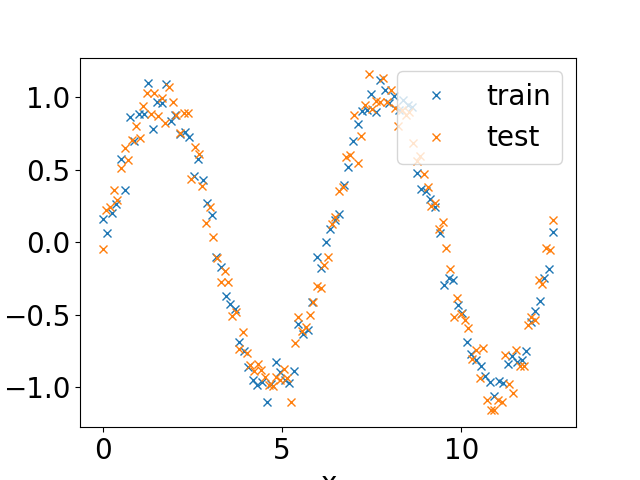

In [3]:
# here is the one-dimensional dataset that we will use
nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")
plt.legend(loc="upper right")

# Use this function to save your plot.
saveplot("a01_2_data.pdf")


## 2b Train with 2 hidden units


In [4]:
# Let's fit the model with one hidden layer consisting of 2 units.
model = train1([2], nreps=1)
print("Training error:", F.mse_loss(y1, model(X1)).item())
print("Test error    :", F.mse_loss(y1test, model(X1test)).item())


X1 shape: torch.Size([100, 1])
Repetition  0:          Current function value: 0.369000
         Iterations: 174
         Function evaluations: 367
         Gradient evaluations: 345
best_cost=0.369
Training error: 0.36900001764297485
Test error    : 0.36961856484413147


C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


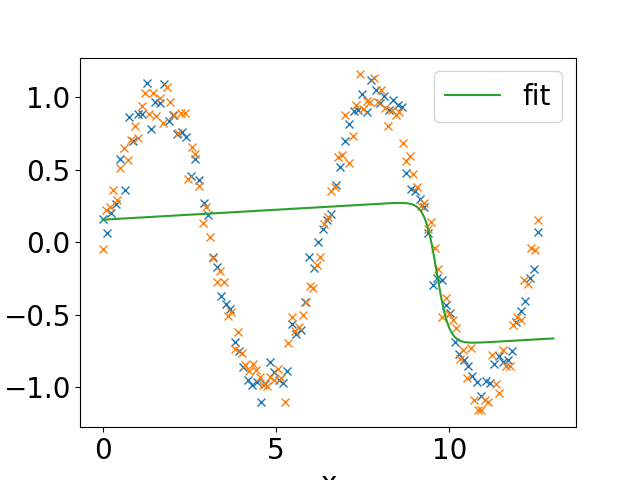

In [5]:
# plot the data and the fit
nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")
plot1fit(torch.linspace(0, 13, 500).unsqueeze(1), model)

saveplot("a01_2_fit-2-neurons.pdf")


In [6]:
# The weight matrices and bias vectors can be read out as follows. If you want, use
# these parameters to compute the output of the network (on X1) directly and compare to
# vmap(model)(X1).
for par, value in model.state_dict().items():
    print(f"{par:<15}= {value}")


0_weight       = tensor([[-5.7129e+00, -1.3309e-03]])
0_bias         = tensor([5.5058e+01, 4.9289e-02])
1_weight       = tensor([[  0.9992],
        [-41.4805]])
1_bias         = tensor([20.4070])


X1 shape: torch.Size([100, 1])
Repetition  0: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.079573
         Iterations: 606
         Function evaluations: 936
         Gradient evaluations: 921
best_cost=0.080
Train iteration 0: 
Training error: 0.07957
Test error    : 0.08671
0_weight       = tensor([[1.0567, 1.0686]])
0_bias         = tensor([-6.6370, -6.7117])
1_weight       = tensor([[-625.8155],
        [ 624.0859]])
1_bias         = tensor([0.8637])
X1 shape: torch.Size([100, 1])
Repetition  0: Optimization terminated successfully.
         Current function value: 0.372710
         Iterations: 78
         Function evaluations: 83
         Gradient evaluations: 83
best_cost=0.373
Train iteration 1: 
Training error: 0.3727
Test error    : 0.374
0_weight       = tensor([[-11.6924, -17.8419]])
0_bias         = tensor([34.2790, 52.1929])
1_weight       = tensor([[ 2.6268],
        [-1.7424]])
1_bias         = tensor([-0.2035])
X1 shape: torch.Size([100, 1])
Repetition  0: Optimization terminated successfully.
         Current function value

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.079573
         Iterations: 379
         Function evaluations: 612
         Gradient evaluations: 600
best_cost=0.080
Train iteration 3: 
Training error: 0.07957
Test error    : 0.08672
0_weight       = tensor([[1.0685, 1.0568]])
0_bias         = tensor([-6.7109, -6.6373])
1_weight       = tensor([[ 632.9709],
        [-634.7004]])
1_bias         = tensor([0.8638])
X1 shape: torch.Size([100, 1])
Repetition  0: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.079574
         Iterations: 361
         Function evaluations: 480
         Gradient evaluations: 473
best_cost=0.080
Train iteration 4: 
Training error: 0.07957
Test error    : 0.08671
0_weight       = tensor([[-1.0699, -1.0555]])
0_bias         = tensor([6.7194, 6.6296])
1_weight       = tensor([[-519.0019],
        [ 520.7314]])
1_bias         = tensor([-0.8657])
X1 shape: torch.Size([100, 1])
Repetition  0: Optimization terminated successfully.
         Current function value: 0.357250
         Iterations: 112
         Function evaluations: 120
         Gradient evaluations: 120
best_cost=0.357
Train iteration 5: 
Training error: 0.3572
Test error    : 0.3594
0_weight       = tensor([[ 6.0143, -5.0166]])
0_bias         = tensor([-3.4539, 13.9791])
1_weight       = tensor([[0.8249],
        [1.1157]])
1_bias         = tensor([-1.0277])
X1 shape: torch.Size([100, 1])
Repetition  0: Optimization terminated successfully.
         Current function valu

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.286909
         Iterations: 783
         Function evaluations: 999
         Gradient evaluations: 989
best_cost=0.287
Train iteration 7: 
Training error: 0.2869
Test error    : 0.2948
0_weight       = tensor([[ 1.5725, -1.5616]])
0_bias         = tensor([-5.2596,  5.2264])
1_weight       = tensor([[-508.6703],
        [-508.3171]])
1_bias         = tensor([508.6768])
X1 shape: torch.Size([100, 1])
Repetition  0: Optimization terminated successfully.
         Current function value: 0.357250
         Iterations: 84
         Function evaluations: 93
         Gradient evaluations: 93
best_cost=0.357
Train iteration 8: 
Training error: 0.3572
Test error    : 0.3594
0_weight       = tensor([[-6.0144, -5.0166]])
0_bias         = tensor([ 3.4540, 13.9791])
1_weight       = tensor([[-0.8249],
        [ 1.1157]])
1_bias         = tensor([-0.2028])
X1 shape: torch.Size([100, 1])
Repetition  0: Optimization terminated successfully.
         Current function valu

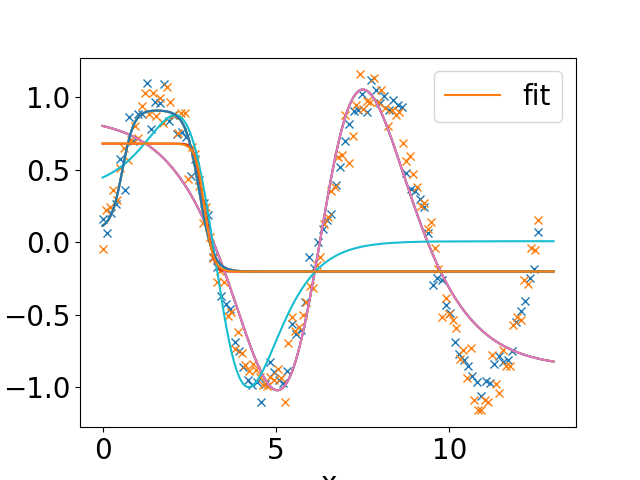

In [7]:
# now repeat this multiple times
nrep = 10
nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")
for i in range(nrep):
    model = train1([2], nreps=1)
    print(f"Train iteration {i}: ")
    print(f"Training error: {F.mse_loss(y1, model(X1)).item():.4}")
    print(f"Test error    : {F.mse_loss(y1test, model(X1test)).item():.4}")
    for par, value in model.state_dict().items():
        print(f"{par:<15}= {value}")
    plot1fit(torch.linspace(0, 13, 500).unsqueeze(1), model)
saveplot("a01_2_fit-2-neurons-multi-iter.pdf")


In [8]:
# From now on, always train multiple times (nreps=10 by default) and report best model.
model = train1([2], nreps=10)
print("Training error:", F.mse_loss(y1, model(X1)).item())
print("Test error    :", F.mse_loss(y1test, model(X1test)).item())


X1 shape: torch.Size([100, 1])
Repetition  0:          Current function value: 0.372919
         Iterations: 45
         Function evaluations: 133
         Gradient evaluations: 122
best_cost=0.373
X1 shape: torch.Size([100, 1])
Repetition  1: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


Optimization terminated successfully.
         Current function value: 0.357250
         Iterations: 117
         Function evaluations: 189
         Gradient evaluations: 178
best_cost=0.357
X1 shape: torch.Size([100, 1])
Repetition  2: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.286909
         Iterations: 342
         Function evaluations: 486
         Gradient evaluations: 476
best_cost=0.287
X1 shape: torch.Size([100, 1])
Repetition  3: Optimization terminated successfully.
         Current function value: 0.357250
         Iterations: 103
         Function evaluations: 124
         Gradient evaluations: 124
best_cost=0.287
X1 shape: torch.Size([100, 1])
Repetition  4: 

...

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.079573
         Iterations: 433
         Function evaluations: 738
         Gradient evaluations: 724
best_cost=0.080
X1 shape: torch.Size([100, 1])
Repetition  6: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.079573
         Iterations: 347
         Function evaluations: 512
         Gradient evaluations: 491
best_cost=0.080
X1 shape: torch.Size([100, 1])
Repetition  7: Optimization terminated successfully.
         Current function value: 0.357250
         Iterations: 88
         Function evaluations: 95
         Gradient evaluations: 95
best_cost=0.080
X1 shape: torch.Size([100, 1])
Repetition  8:          Current function value: 0.079573
         Iterations: 346
         Function evaluations: 483
         Gradient evaluations: 471
best_cost=0.080
X1 shape: torch.Size([100, 1])
Repetition  9: Optimization terminated successfully.
         Current function value: 0.357250
         Iterations: 86
         Function evaluations: 95
         Gradient evaluations: 95
best_cost=0.080
Training error: 0.07957081496715546
Test error    : 0.08671221137046814


C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


## 2c Width


In [9]:
# Experiment with different hidden layer sizes. To avoid recomputing
# models, you may want to save your models using torch.save(model, filename) and
# load them again using torch.load(filename).
# Model Train
# widths = [1, 2, 3, 10, 50, 100]
#
# for w in widths:
#     model = train1([w], nreps=10)
#     models[w] = model
#     torch.save(model, f"model_width_{w}.pt")
#     print(f"Hidden layer width: {w}")
#     print("Training error:", F.mse_loss(y1, model(X1)).item())
#     print("Test error    :", F.mse_loss(y1test, model(X1test)).item())

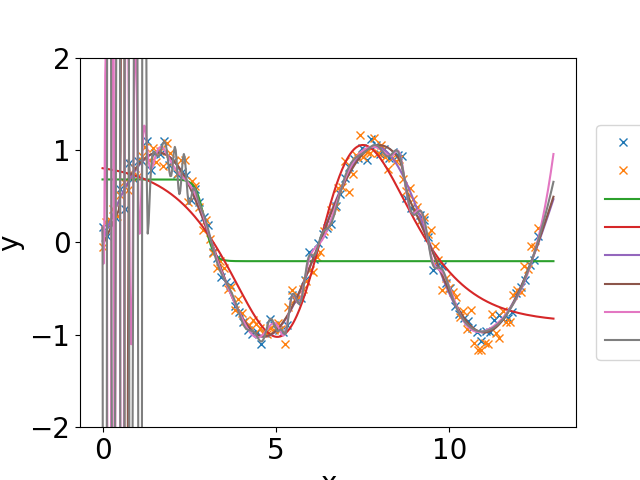

In [16]:
# No need to train again, load and use
# Load Models and graph
models = {}
widths = [1, 2, 3, 10, 50, 100]
for w in widths:
    model = torch.load(f"model_width_{w}.pt")
    models[w] = model

nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")

Xplot = torch.linspace(0, 13, 500).unsqueeze(1)
for w, model in models.items():
    plot1fit(Xplot, model, label=f"fit (m={w})")

# Label fix
ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()

seen = set()
new_handles = []
new_labels = []
for h, l in zip(handles, labels):
    if l not in seen:
        new_handles.append(h)
        new_labels.append(l)
        seen.add(l)

ax.legend(new_handles, new_labels,
          loc="center left",
          bbox_to_anchor=(1.02, 0.5),
          fontsize=15,
          labelspacing=0.4,
          borderpad=0.4,
          handlelength=1.8)

plt.ylim(-2, 2)
saveplot("a01_2_c_fit-n-neurons.pdf")

## 2d Distributed representations


In [34]:
# train a model to analyze
model = train1([10])
for par, value in model.state_dict().items():
        print(f"{par:<15}= {value}")



X1 shape: torch.Size([100, 1])
Repetition  0: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.006229
         Iterations: 2097
         Function evaluations: 2433
         Gradient evaluations: 2424
best_cost=0.006
X1 shape: torch.Size([100, 1])
Repetition  1: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.006584
         Iterations: 2370
         Function evaluations: 2683
         Gradient evaluations: 2671
best_cost=0.006
X1 shape: torch.Size([100, 1])
Repetition  2: 

...

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.006544
         Iterations: 2126
         Function evaluations: 2387
         Gradient evaluations: 2378
best_cost=0.006
X1 shape: torch.Size([100, 1])
Repetition  8: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.006586
         Iterations: 2246
         Function evaluations: 2569
         Gradient evaluations: 2559
best_cost=0.006
X1 shape: torch.Size([100, 1])
Repetition  9:          Current function value: 0.005957
         Iterations: 1328
         Function evaluations: 1632
         Gradient evaluations: 1615
best_cost=0.006
0_weight       = tensor([[ 21.3529,  17.1161,   2.2363,  -2.1110,  -1.0323,   9.9860,  -0.3979,
         -13.2372,  -1.1045,   0.7458]])
0_bias         = tensor([-12.9025, -12.8243,  -7.9263,   7.4310,  10.4340,   5.4274,   6.8816,
          9.1665,   9.5515,  -6.5959])
1_weight       = tensor([[ -5.1417],
        [ -8.8975],
        [ 12.7612],
        [ 16.0554],
        [ 10.5895],
        [-13.6413],
        [-22.3860],
        [-14.9062],
        [ 15.5020],
        [ 26.0886]])
1_bias         = tensor([8.8253])


C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


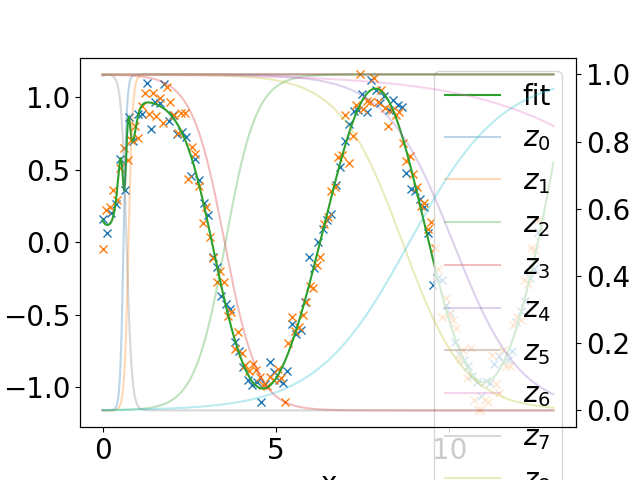

In [35]:
# plot the fit as well as the outputs of each neuron in the hidden
# layer (scale for the latter is shown on right y-axis)
nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")
plot1fit(torch.linspace(0, 13, 500).unsqueeze(1), model, hidden=True, scale=False)
saveplot("a01_2_distributed-reps-n10.pdf")


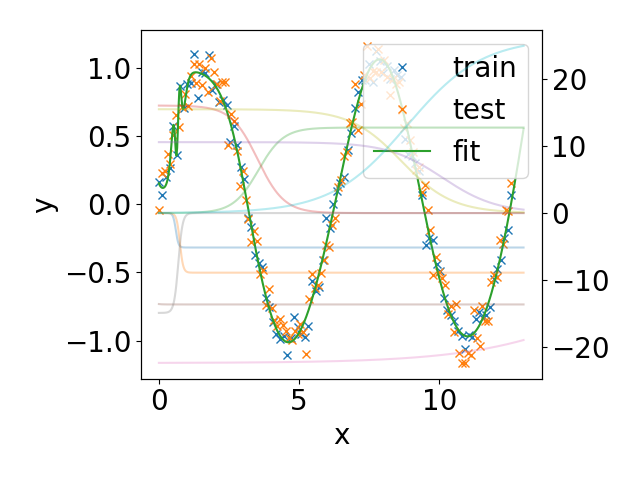

In [36]:
# plot the fit as well as the outputs of each neuron in the hidden layer, scaled
# by its weight for the output neuron (scale for the latter is shown on right
# y-axis)

nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")
plot1fit(torch.linspace(0, 13, 500).unsqueeze(1), model, hidden=True, scale=True)
plt.legend(loc="upper right")
plt.tight_layout()
saveplot("a01_2_distributed-reps-scaled-n10.pdf")


## 2e Experiment with different optimizers (optional)


In [37]:
# PyTorch provides many gradient-based optimizers; see
# https://pytorch.org/docs/stable/optim.html. You can use a PyTorch optimizer
# as follows.
train_adam = lambda model, **kwargs: fnn_train(
    X1, y1, model, optimizer=torch.optim.Adam(model.parameters(), lr=0.01), **kwargs
)
model = train1([50], nreps=1, train=train_adam, max_epochs=5000, tol=1e-8, verbose=True)


X1 shape: torch.Size([100, 1])
Repetition  0: Epoch     0: cost=   4.835 
Epoch     1: cost=   3.766 
Epoch     2: cost=   2.862 
Epoch     3: cost=   2.120 
Epoch     4: cost=   1.535 
Epoch     5: cost=   1.101 
Epoch     6: cost=   0.805 
Epoch     7: cost=   0.632 
Epoch     8: cost=   0.561 
Epoch     9: cost=   0.569 
Epoch    10: cost=   0.627 
Epoch    11: cost=   0.710 
Epoch    12: cost=   0.793 
Epoch    13: cost=   0.860 
Epoch    14: cost=   0.900 
Epoch    15: cost=   0.910 
Epoch    16: cost=   0.890 
Epoch    17: cost=   0.847 
Epoch    18: cost=   0.787 
Epoch    19: cost=   0.718 
Epoch    20: cost=   0.649 
Epoch    21: cost=   0.585 
Epoch    22: cost=   0.531 
Epoch    23: cost=   0.491 
Epoch    24: cost=   0.465 
Epoch    25: cost=   0.452 
Epoch    26: cost=   0.450 
Epoch    27: cost=   0.458 
Epoch    28: cost=   0.470 
Epoch    29: cost=   0.484 
Epoch    30: cost=   0.497 
Epoch    31: cost=   0.507 
Epoch    32: cost=   0.512 
Epoch    33: cost=   0.512 
Ep

X1 shape: torch.Size([100, 1])
Repetition  0: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.430039
         Iterations: 133
         Function evaluations: 256
         Gradient evaluations: 245
best_cost=0.430
X1 shape: torch.Size([100, 1])
Repetition  1: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.268690
         Iterations: 145
         Function evaluations: 339
         Gradient evaluations: 333
best_cost=0.269
X1 shape: torch.Size([100, 1])
Repetition  2: Optimization terminated successfully.
         Current function value: 0.506238
         Iterations: 11
         Function evaluations: 13
         Gradient evaluations: 13
best_cost=0.269
X1 shape: torch.Size([100, 1])
Repetition  3:          Current function value: 0.435274
         Iterations: 28
         Function evaluations: 120
         Gradient evaluations: 116
best_cost=0.269
X1 shape: torch.Size([100, 1])
Repetition  4: 

...

         Current function value: 0.028834
         Iterations: 73
         Function evaluations: 222
         Gradient evaluations: 209
best_cost=0.010
X1 shape: torch.Size([100, 1])
Repetition  47: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.355967
         Iterations: 106
         Function evaluations: 202
         Gradient evaluations: 196
best_cost=0.010
X1 shape: torch.Size([100, 1])
Repetition  48: 

C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)
C:\Users\LENOVO\miniconda3\envs\dl-pi1\Lib\site-packages\scipy\optimize\_minimize.py:779: OptimizeWarning: Desired error not necessarily achieved due to precision loss.
  res = _minimize_bfgs(fun, x0, args, jac, callback, **options)


         Current function value: 0.081983
         Iterations: 256
         Function evaluations: 389
         Gradient evaluations: 380
best_cost=0.010
X1 shape: torch.Size([100, 1])
Repetition  49:          Current function value: 0.356298
         Iterations: 46
         Function evaluations: 149
         Gradient evaluations: 144
best_cost=0.010
Training error: 0.010111200623214245
Test error    : 0.013382363133132458


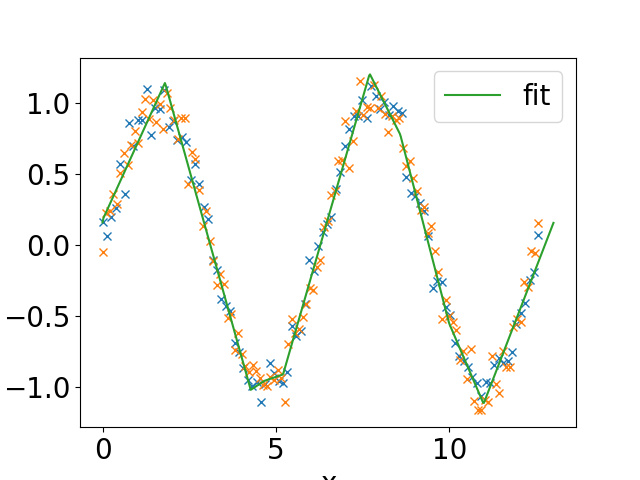

In [38]:
# Experiment with different number of layers and activation functions. Here is
# an example with three hidden layers (of sizes 4, 5, and 6) and ReLU activations.
#
# You can also plot the outputs of the hidden neurons in the first layer (using
# the same code above).
model = train1([4, 5, 6], nreps=50, phi=F.relu)
nextplot()
plot1(X1, y1, label="train")
plot1(X1test, y1test, label="test")
plot1fit(torch.linspace(0, 13, 500).unsqueeze(1), model)
print("Training error:", F.mse_loss(y1, model(X1)).item())
print("Test error    :", F.mse_loss(y1test, model(X1test)).item())
